# Laboratorio 3 - Mineria de Datos 
### SmartStay Linear Regression Model
- Fabian Prado #23427
- Sofia Lopez #
- Jonathan Zacarias #

### Imports

In [2]:
import pyreadr
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
SEED = 42 # reproducibilidad

warnings.filterwarnings("ignore")

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

---

## Lectura de datos

In [3]:
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]

In [4]:
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


---

## Descripcion y Limpieza de Datos

In [5]:
# Dimensiones y tipos de dato
print(f"Dimensiones: {listings_df.shape[0]:,} filas × {listings_df.shape[1]} columnas\n")
print("Tipos de dato por columna:")
print(listings_df.dtypes.value_counts())

# Ciudades
print("\nCiudades en el dataset:")
print(listings_df['city'].value_counts())

# Valores nulos
missing = pd.DataFrame({
    'nulos': listings_df.isnull().sum(),
    'pct':   (listings_df.isnull().sum() / len(listings_df) * 100).round(2)
})
missing = missing[missing['nulos'] > 0].sort_values('pct', ascending=False)
print(f"\nVariables con valores nulos ({len(missing)} de {listings_df.shape[1]}):")
print(missing.to_string())

Dimensiones: 171,748 filas × 80 columnas

Tipos de dato por columna:
object     47
int32      18
float64    15
Name: count, dtype: int64

Ciudades en el dataset:
city
Los Angeles, California      45585
New York, New York           36261
Hawaii                       33457
San Diego, California        13162
Austin, Texas                10533
Chicago, Illinois             8660
San Francisco, California     7535
Washington, D.C.              6374
Rhode Island                  5762
Boston, Massachusetts         4419
Name: count, dtype: int64

Variables con valores nulos (23 de 80):
                               nulos     pct
calendar_updated              171748  100.00
estimated_revenue_l365d        95502   55.61
price                          89381   52.04
neighbourhood_group_cleansed   50683   29.51
review_scores_value            40328   23.48
review_scores_location         40328   23.48
review_scores_checkin          40324   23.48
review_scores_communication    40308   23.47
review_scor

In [6]:
df_with_price = listings_df[listings_df['price'].notna()].copy()
print(f"Filas con precio valido: {len(df_with_price):,}")
print(f"Filas descartadas (sin precio): {len(listings_df) - len(df_with_price):,} ({(1 - len(df_with_price)/len(listings_df))*100:.1f}%)")

print(f"\nNulos restantes dentro de filas con precio valido:")
for col in ['bathrooms', 'bedrooms', 'beds']:
    n = df_with_price[col].isna().sum()
    pct = n / len(df_with_price) * 100
    print(f"  {col}: {n:,} ({pct:.1f}%)")

Filas con precio valido: 82,367
Filas descartadas (sin precio): 89,381 (52.0%)

Nulos restantes dentro de filas con precio valido:
  bathrooms: 5,580 (6.8%)
  bedrooms: 1,131 (1.4%)
  beds: 5,679 (6.9%)


El dataset contiene **171,748 registros** y **80 variables** correspondientes a listados 
de Airbnb en 10 ciudades de Estados Unidos. Las ciudades con mayor representación son 
Los Ángeles (45,585), Nueva York (36,261) y Hawaii (33,457).

Las variables se clasifican en tres tipos:
- **47 variables de tipo object** (categóricas o texto libre)
- **18 variables enteras (int32)** (conteos, disponibilidad, noches)
- **15 variables numéricas (float64)** (coordenadas, scores, precio)

De las 80 variables, **23 presentan valores nulos**. Los casos más críticos son:
- `calendar_updated`: 100% nulos -> se elimina la columna completamente
- `price`: 52% nulos -> se eliminan las filas sin precio, dejando **82,367 registros** utiles para el modelado
- `estimated_revenue_l365d`: 55% nulos -> se evaluara su importancia mas adelante
- `review_scores_*`: ~23% nulos -> corresponden a propiedades sin resenas suficientes, se conservan tal cual
- `bedrooms`: 1.4% nulos dentro de los registros con precio valido -> se eliminan las filas (perdida negligible)
- `bathrooms` y `beds`: ~6.8% nulos dentro de los registros con precio valido -> se imputan con la mediana por `room_type`

In [7]:
priced_listings_df = df_with_price.drop(['calendar_updated'], axis=1).copy()

missing = pd.DataFrame({
    'nulos': priced_listings_df.isnull().sum(),
    'pct':   (priced_listings_df.isnull().sum() / len(priced_listings_df) * 100).round(2)
})
missing = missing[missing['nulos'] > 0].sort_values('pct', ascending=False)
print(f"\nVariables con valores nulos en dataset con precio ({len(missing)} de {priced_listings_df.shape[1]}):")
print(missing.to_string())


Variables con valores nulos en dataset con precio (20 de 79):
                              nulos    pct
neighbourhood_group_cleansed  43148  52.39
review_scores_value           15062  18.29
review_scores_location        15062  18.29
review_scores_checkin         15062  18.29
review_scores_accuracy        15061  18.29
reviews_per_month             15055  18.28
review_scores_rating          15055  18.28
review_scores_communication   15060  18.28
review_scores_cleanliness     15060  18.28
license                       10533  12.79
estimated_revenue_l365d        6121   7.43
beds                           5679   6.89
bathrooms                      5580   6.77
bedrooms                       1131   1.37
host_total_listings_count       666   0.81
host_listings_count             666   0.81
maximum_maximum_nights           48   0.06
minimum_maximum_nights           48   0.06
maximum_minimum_nights           48   0.06
minimum_minimum_nights           48   0.06


Dentro de los **82,367 registros con precio valido**, se identificaron 20 variables con nulos restantes.
Las decisiones de preprocesamiento son las siguientes:

**Variables eliminadas:**
- `neighbourhood_group_cleansed`: 52% nulos -> se elimina la columna
- `license`: 12.79% nulos -> no es relevante para predecir el precio
- `review_scores_*` y `reviews_per_month`: se eliminan porque reflejan el desempeno del listing despues de su publicacion y la experiencia de los huespedes, no caracteristicas intrinsecas de la propiedad disponibles al momento de fijar el precio. Incluirlas haria el modelo menos interpretable
- `neighbourhood_cleansed`: alta cardinalidad -> se elimina, `city` ya captura la informacion geografica relevante


**Variables imputadas:**
- `bedrooms`: 1.4% nulos dentro de los registros con precio valido -> se imputan con la misma estrategia que bathrooms y beds
- `bathrooms` y `beds`: ~6.8% nulos dentro de los registros con precio valido -> se imputan con mediana por `property_type`, respaldo a `room_type`, luego mediana global
- `host_total_listings_count`: 0.81% nulos -> mediana global, es un conteo general del host
- `host_has_profile_pic`, `host_identity_verified`: nulos minimos -> moda global (variables binarias)

**Variables de host response (opcionales):**
- `host_response_time`, `host_response_rate`, `host_acceptance_rate` -> reflejan el perfil de respuesta del host, que puede influir en la percepcion de precio. Se conservan e imputan con mediana global tras su conversion numerica

**Indicadores de imputacion (missing flags):**
- Se crean variables binarias para `bedrooms`, `host_total_listings_count`, `host_has_profile_pic`, `host_identity_verified`, `host_response_time`, `host_response_rate` y `host_acceptance_rate` que indican si el valor original era nulo. Esto permite al modelo capturar si la ausencia del dato es en si misma informativa

**Extras**
- `host_is_superhost`: valores nulos tras conversion t/f -> se agrega flag y se imputa con moda
- `estimated_revenue_l365d`: se elimina -> no es una caracteristica intrinseca de la propiedad, refleja desempeno de mercado y contaminaria la interpretacion del modelo de precio

#### Drop columnas inutiles

In [8]:
cols_to_drop = [
    'listing_url', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url',
    'id', 'scrape_id', 'host_id',
    'name', 'description', 'neighborhood_overview', 'host_about', 'amenities',
    'last_scraped', 'host_since', 'calendar_last_scraped', 'first_review', 'last_review',
    'host_verifications', 'host_location', 'host_name', 'neighbourhood', 'bathrooms_text', 'source',
    'license', 'neighbourhood_group_cleansed', 'host_neighbourhood',
    'host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    'maximum_maximum_nights', 'minimum_maximum_nights',
    'maximum_minimum_nights', 'minimum_minimum_nights'
]
cols_to_drop = [c for c in cols_to_drop if c in priced_listings_df.columns]
priced_listings_df = priced_listings_df.drop(columns=cols_to_drop)

#### Convertir porcentajes a float

In [9]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    priced_listings_df[col] = (
        priced_listings_df[col]
        .str.rstrip('%')
        .str.strip()
        .replace({'N/A': np.nan, '': np.nan})
        .astype(float)
    )

#### Convertir t/f a 1/0

In [10]:
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    priced_listings_df[col] = priced_listings_df[col].map({'t': 1, 'f': 0})

#### Codificar host_response_time como ordinal

In [11]:
priced_listings_df['host_response_time'] = (
    priced_listings_df['host_response_time']
    .str.strip()
    .replace({'N/A': np.nan, '': np.nan})
    .map({'within an hour': 4, 'within a few hours': 3, 'within a day': 2, 'a few days or more': 1})
)

#### Crear missing flags

In [12]:
for col in ['bedrooms', 'host_total_listings_count', 'host_has_profile_pic',
            'host_identity_verified', 'host_response_time', 'host_response_rate', 'host_acceptance_rate']:
    priced_listings_df[f'{col}_missing'] = priced_listings_df[col].isna().astype(int)

#### Imputar datos faltantes

In [13]:
# Imputar bathrooms, beds, bedrooms: property_type -> room_type -> global median
def impute_hierarchy(df, col):
    by_property = df.groupby('property_type')[col].median()
    by_room     = df.groupby('room_type')[col].median()
    global_med  = df[col].median()
    def _impute(row):
        if pd.notna(row[col]):
            return row[col]
        val = by_property.get(row['property_type'])
        if pd.notna(val):
            return val
        val = by_room.get(row['room_type'])
        if pd.notna(val):
            return val
        return global_med
    return df.apply(_impute, axis=1)

for col in ['bathrooms', 'beds', 'bedrooms']:
    priced_listings_df[col] = impute_hierarchy(priced_listings_df, col)

# Imputar host_has_profile_pic, host_identity_verified con moda
for col in ['host_has_profile_pic', 'host_identity_verified']:
    priced_listings_df[col] = priced_listings_df[col].fillna(priced_listings_df[col].mode()[0])

# Imputar host_total_listings_count con mediana
priced_listings_df['host_total_listings_count'] = (
    priced_listings_df['host_total_listings_count']
    .fillna(priced_listings_df['host_total_listings_count'].median())
)

# Imputar host response variables con mediana
for col in ['host_response_time', 'host_response_rate', 'host_acceptance_rate']:
    priced_listings_df[col] = priced_listings_df[col].fillna(priced_listings_df[col].median())

# Flag de imputar host_is_superhost
priced_listings_df['host_is_superhost_missing'] = priced_listings_df['host_is_superhost'].isna().astype(int)
priced_listings_df['host_is_superhost'] = priced_listings_df['host_is_superhost'].fillna(
    priced_listings_df['host_is_superhost'].mode()[0]
)

#### Eliminar columnas finales

In [14]:
# Eliminar columnas de reviews
review_cols = [c for c in priced_listings_df.columns if 'review_scores' in c] + ['reviews_per_month']
priced_listings_df = priced_listings_df.drop(columns=review_cols)

# Eliminar estimated_revenue_l365d
priced_listings_df = priced_listings_df.drop(columns=['estimated_revenue_l365d'])

# Eliminar neighbourhood_cleansed
priced_listings_df = priced_listings_df.drop(columns=['neighbourhood_cleansed'])

#### Convertir Price a Numerico

In [15]:
priced_listings_df['price'] = (
    priced_listings_df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)

#### Convertir has_availability a binario

In [16]:
priced_listings_df['has_availability'] = priced_listings_df['has_availability'].map({'t': 1, 'f': 0})

In [17]:
print(f"Dimensiones finales: {priced_listings_df.shape}")
print(f"\nColumnas object restantes:")
print(priced_listings_df.select_dtypes(include='object').columns.tolist())
print(f"\nTipos de dato:")
print(priced_listings_df.dtypes.value_counts())

Dimensiones finales: (82367, 42)

Columnas object restantes:
['property_type', 'room_type', 'city']

Tipos de dato:
float64    16
int32      14
int64       9
object      3
Name: count, dtype: int64


Tras el proceso de limpieza y preprocesamiento, el dataset queda con **82,367 registros** y **42 variables**, 
listo para el analisis exploratorio y el modelado. Las unicas variables de tipo object restantes son 
`property_type`, `room_type` y `city`, las cuales seran codificadas mediante one-hot encoding en la 
etapa de ingenieria de caracteristicas.

Resumen del proceso:
- Se eliminaron **89,381 filas** sin precio reportado
- Se eliminaron **38 columnas** entre identificadores, texto libre, URLs, variables redundantes y variables de desempeno post-publicacion
- Se imputaron `bathrooms`, `beds` y `bedrooms` con jerarquia property_type -> room_type -> mediana global
- Se imputaron variables de host con mediana o moda segun su naturaleza
- Se crearon **8 missing flags** para variables con nulos informativos
- La variable objetivo `price` queda en formato numerico (float64)

---

## Analisis Exploratorio de Datos

In [18]:
print("Columnas numericas:")
print(priced_listings_df.select_dtypes(include=np.number).columns.tolist())

print(f"\nEstadisticas de price:")
print(priced_listings_df['price'].describe().round(2))

print(f"\nValores extremos de price:")
print(f"  Max: ${priced_listings_df['price'].max():,.2f}")
print(f"  Percentil 99: ${priced_listings_df['price'].quantile(0.99):,.2f}")
print(f"  Percentil 95: ${priced_listings_df['price'].quantile(0.95):,.2f}")
print(f"  Median: ${priced_listings_df['price'].median():,.2f}")

Columnas numericas:
['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'instant_bookable', 'calculated_host_listings_count', 'bedrooms_missing', 'host_total_listings_count_missing', 'host_has_profile_pic_missing', 'host_identity_verified_missing', 'host_response_time_missing', 'host_response_rate_missing', 'host_acceptance_rate_missing', 'host_is_superhost_missing']

Estadisticas de price:
count    76246.00
mean       750.51
std       4250.61
min          8.00
25% 

Tras convertir `price` a un numero, aun tenemos strings, por lo que eliminamos esas filas

In [19]:
priced_listings_df = priced_listings_df.dropna(subset=['price'])
print(f"Dimensiones tras eliminar nulos en price: {priced_listings_df.shape}")

Dimensiones tras eliminar nulos en price: (76246, 42)


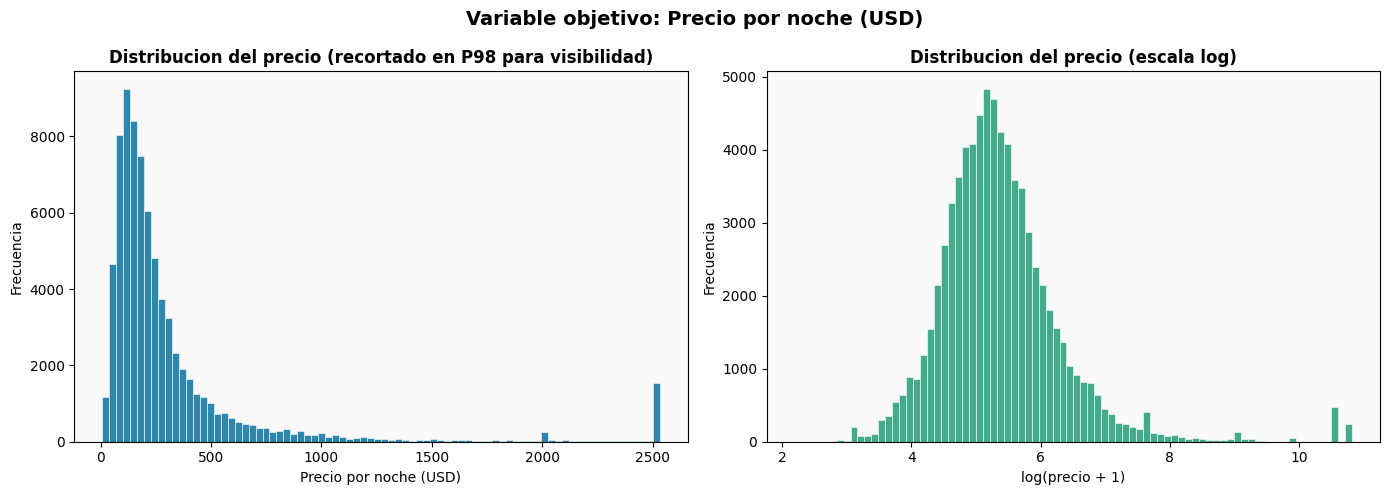

In [20]:
p98 = priced_listings_df['price'].quantile(0.98)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    priced_listings_df['price'].clip(upper=p98),
    bins=80, color='#2E86AB', edgecolor='white', linewidth=0.4
)
axes[0].set_title('Distribucion del precio (recortado en P98 para visibilidad)', fontweight='bold')
axes[0].set_xlabel('Precio por noche (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(
    np.log1p(priced_listings_df['price']),
    bins=80, color='#43AA8B', edgecolor='white', linewidth=0.4
)
axes[1].set_title('Distribucion del precio (escala log)', fontweight='bold')
axes[1].set_xlabel('log(precio + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Variable objetivo: Precio por noche (USD)', fontsize=14, fontweight='bold')
for ax in axes:
    ax.grid(False) # odio el grid
plt.tight_layout()
plt.show()

La variable objetivo `price` presenta una distribucion fuertemente sesgada a la derecha. 
La gran mayoria de los listings se concentra entre $50 y $500 USD por noche, con una mediana 
de $193, pero existen valores extremos que superan los $50,000 USD que corresponden a 
propiedades de lujo o listings atipicos. 

En escala logaritmica, la distribucion se aproxima a una normal, lo que sugiere que trabajar 
con `log(price)` mejorara el desempeno de los modelos de regresion lineal al cumplir mejor 
con el supuesto de normalidad de los residuos. Esta transformacion sera considerada en la 
etapa de modelado.

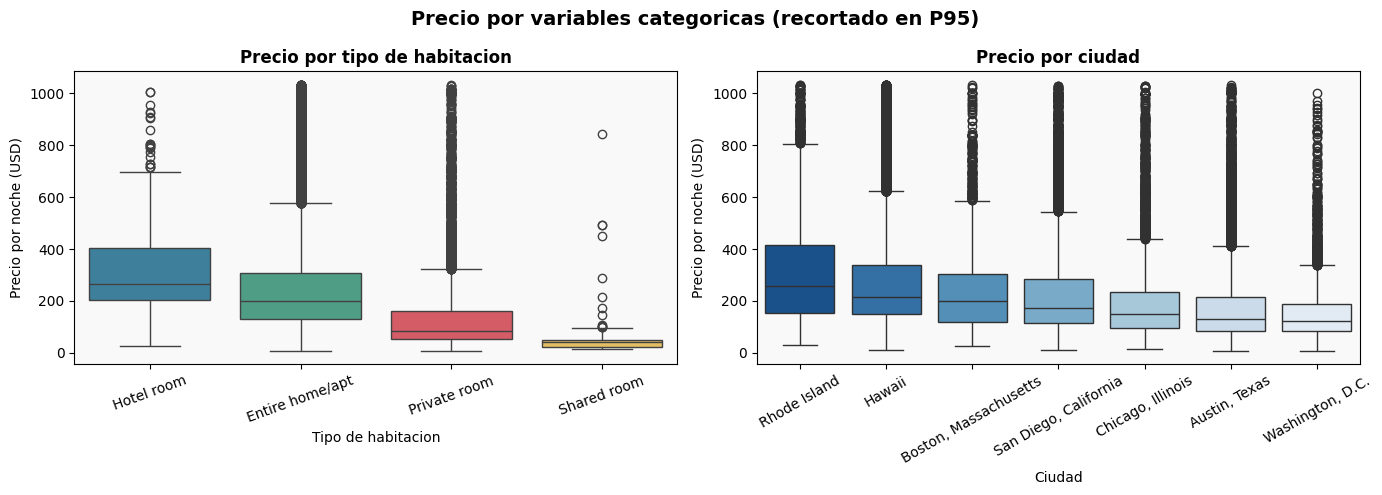

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = priced_listings_df['price'].quantile(0.95)
plot_df = priced_listings_df[priced_listings_df['price'] <= p95]

# room_type vs price
room_order = plot_df.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='room_type', y='price', order=room_order,
            palette=['#2E86AB', '#43AA8B', '#E84855', '#F9C74F'], ax=axes[0])
axes[0].set_title('Precio por tipo de habitacion', fontweight='bold')
axes[0].set_xlabel('Tipo de habitacion')
axes[0].set_ylabel('Precio por noche (USD)')
axes[0].tick_params(axis='x', rotation=20)

# city vs price
city_order = plot_df.groupby('city')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, x='city', y='price', order=city_order,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Precio por ciudad', fontweight='bold')
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Precio por noche (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Precio por variables categoricas (recortado en P95)', fontsize=14, fontweight='bold')
for ax in axes:
    ax.grid(False) # odio el grid
plt.tight_layout()
plt.show()

**Precio por tipo de habitacion:**
El tipo de habitacion es uno de los predictores mas claros del precio. Los hoteles (`Hotel room`) 
presentan la mediana mas alta (~$260), seguidos de propiedades completas (`Entire home/apt`, ~$200). 
Las habitaciones privadas (`Private room`) tienen precios significativamente menores (~$100), y las 
habitaciones compartidas (`Shared room`) son las mas economicas (~$40). Esta variable sera un 
predictor importante en el modelo y debera ser codificada mediante one-hot encoding.

**Precio por ciudad:**
Existe variacion considerable entre ciudades. Rhode Island y Hawaii presentan las medianas mas altas, 
mientras que Washington D.C. y Austin tienen los precios mas bajos. Esto confirma que `city` captura 
informacion geografica relevante para predecir el precio y debe incluirse en el modelo. Cabe notar 
que todas las ciudades presentan una cantidad importante de outliers hacia precios altos, lo cual es 
consistente con el sesgo derecho observado en la distribucion general del precio.

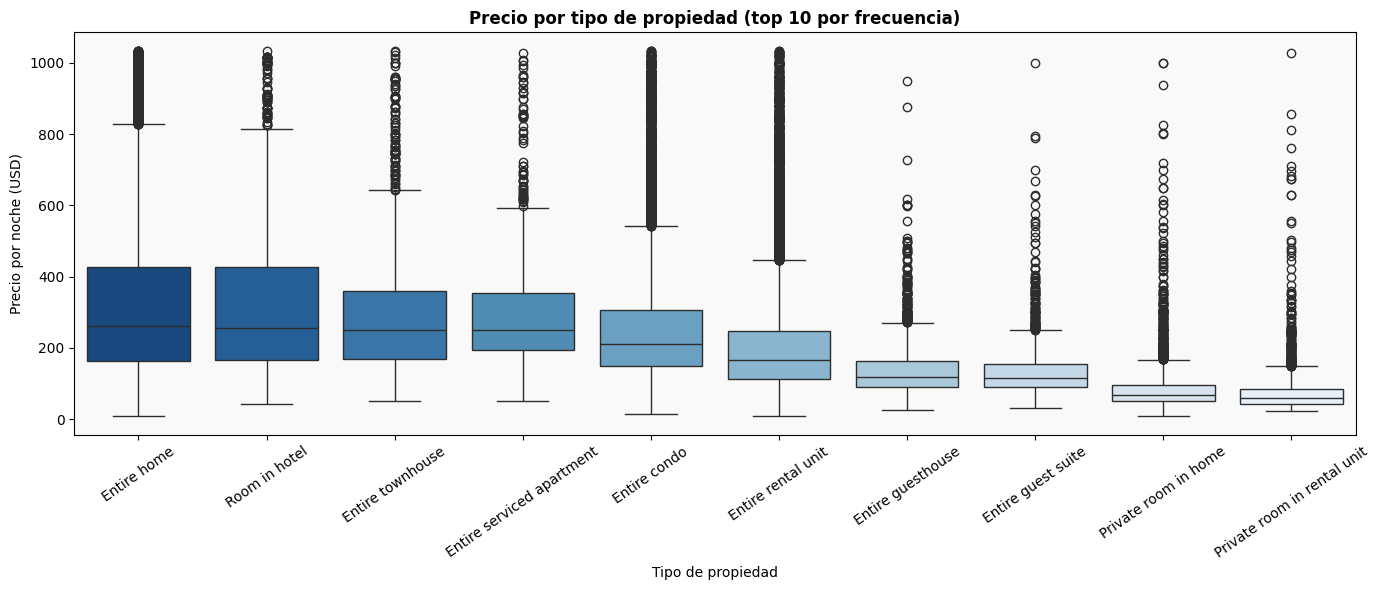

In [22]:
top10_property = (
    priced_listings_df['property_type']
    .value_counts()
    .head(10)
    .index
)

plot_df_prop = priced_listings_df[
    (priced_listings_df['property_type'].isin(top10_property)) &
    (priced_listings_df['price'] <= p95)
]

fig, ax = plt.subplots(figsize=(14, 6))

prop_order = plot_df_prop.groupby('property_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df_prop, x='property_type', y='price',
            order=prop_order, palette='Blues_r', ax=ax)
ax.set_title('Precio por tipo de propiedad (top 10 por frecuencia)', fontweight='bold')
ax.set_xlabel('Tipo de propiedad')
ax.set_ylabel('Precio por noche (USD)')
ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.grid(False)
plt.show()

In [23]:
priced_listings_df['property_type'].nunique()

94

Los 10 tipos de propiedad mas frecuentes muestran una clara separacion entre propiedades completas 
y habitaciones privadas. `Entire home` y `Room in hotel` presentan las medianas mas altas (~$260), 
mientras que `Private room in home` y `Private room in rental unit` tienen las medianas mas bajas 
(~$65). Sin embargo, dado que `property_type` cuenta con mas de 94 valores unicos, su inclusion 
directa en el modelo mediante one-hot encoding generaria mas de 94 columnas adicionales, 
incrementando innecesariamente la complejidad. Dado que `room_type` captura la misma separacion 
estructural con solo 4 categorias, se decide eliminar `property_type` del dataset final.

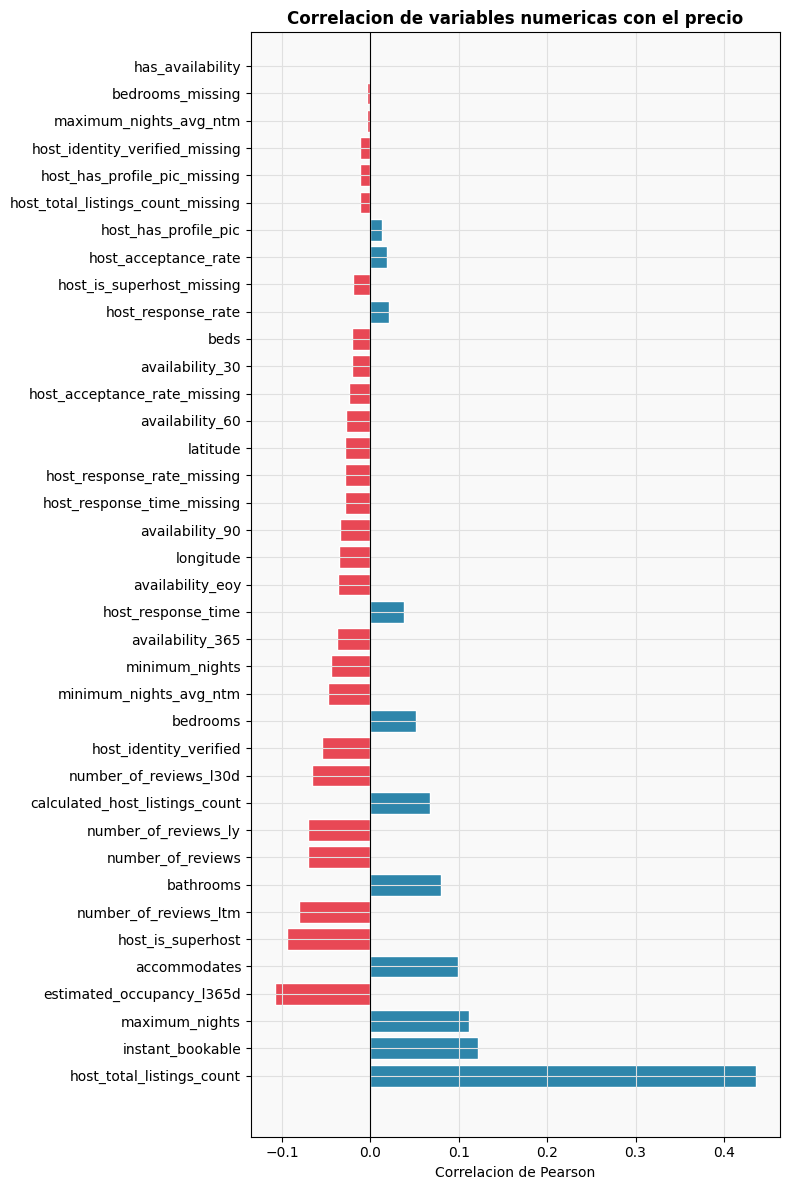

In [24]:
numeric_cols = priced_listings_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price']

corr_with_price = (
    priced_listings_df[numeric_cols + ['price']]
    .corr()['price']
    .drop('price')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 12))
colors = ['#2E86AB' if v >= 0 else '#E84855' for v in corr_with_price.values]
ax.barh(corr_with_price.index, corr_with_price.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlacion de variables numericas con el precio', fontweight='bold')
ax.set_xlabel('Correlacion de Pearson')
plt.tight_layout()
plt.show()

El analisis de correlacion de Pearson revela que ninguna variable numerica tiene una correlacion extremadamente 

Los hallazgos mas relevantes son:

- `host_total_listings_count` presenta la correlacion positiva mas alta (~0.43), lo que sugiere 
  que hosts con mas propiedades tienden a cobrar precios mas altos, posiblemente porque son 
  operadores profesionales con propiedades de mayor calidad
- `instant_bookable` y `maximum_nights` muestran correlaciones positivas moderadas (~0.12), 
  indicando que propiedades con mayor flexibilidad de reserva y estancia tienden a tener 
  precios mas altos
- `accommodates` y `bathrooms` tienen correlaciones positivas esperadas (~0.10 y ~0.08), 
  confirmando que propiedades mas grandes cobran mas
- `estimated_occupancy_l365d` y `host_is_superhost` muestran correlaciones negativas, lo que 
  podria indicar que propiedades con alta ocupacion compiten por precio, y que superhosts 
  priorizan ocupacion sobre precio maximo
- Las variables de missing flags y disponibilidad tienen correlaciones cercanas a cero, 
  confirmando que no son predictores directos del precio

Para el analisis de dispersion se seleccionan las variables continuas con mayor correlacion 
absoluta con el precio: `host_total_listings_count`, `maximum_nights`, `accommodates`, 
`bathrooms`, `bedrooms` y `estimated_occupancy_l365d`. Variables binarias como `instant_bookable` 
se excluyen de los scatterplots ya que no producen visualizaciones interpretables.

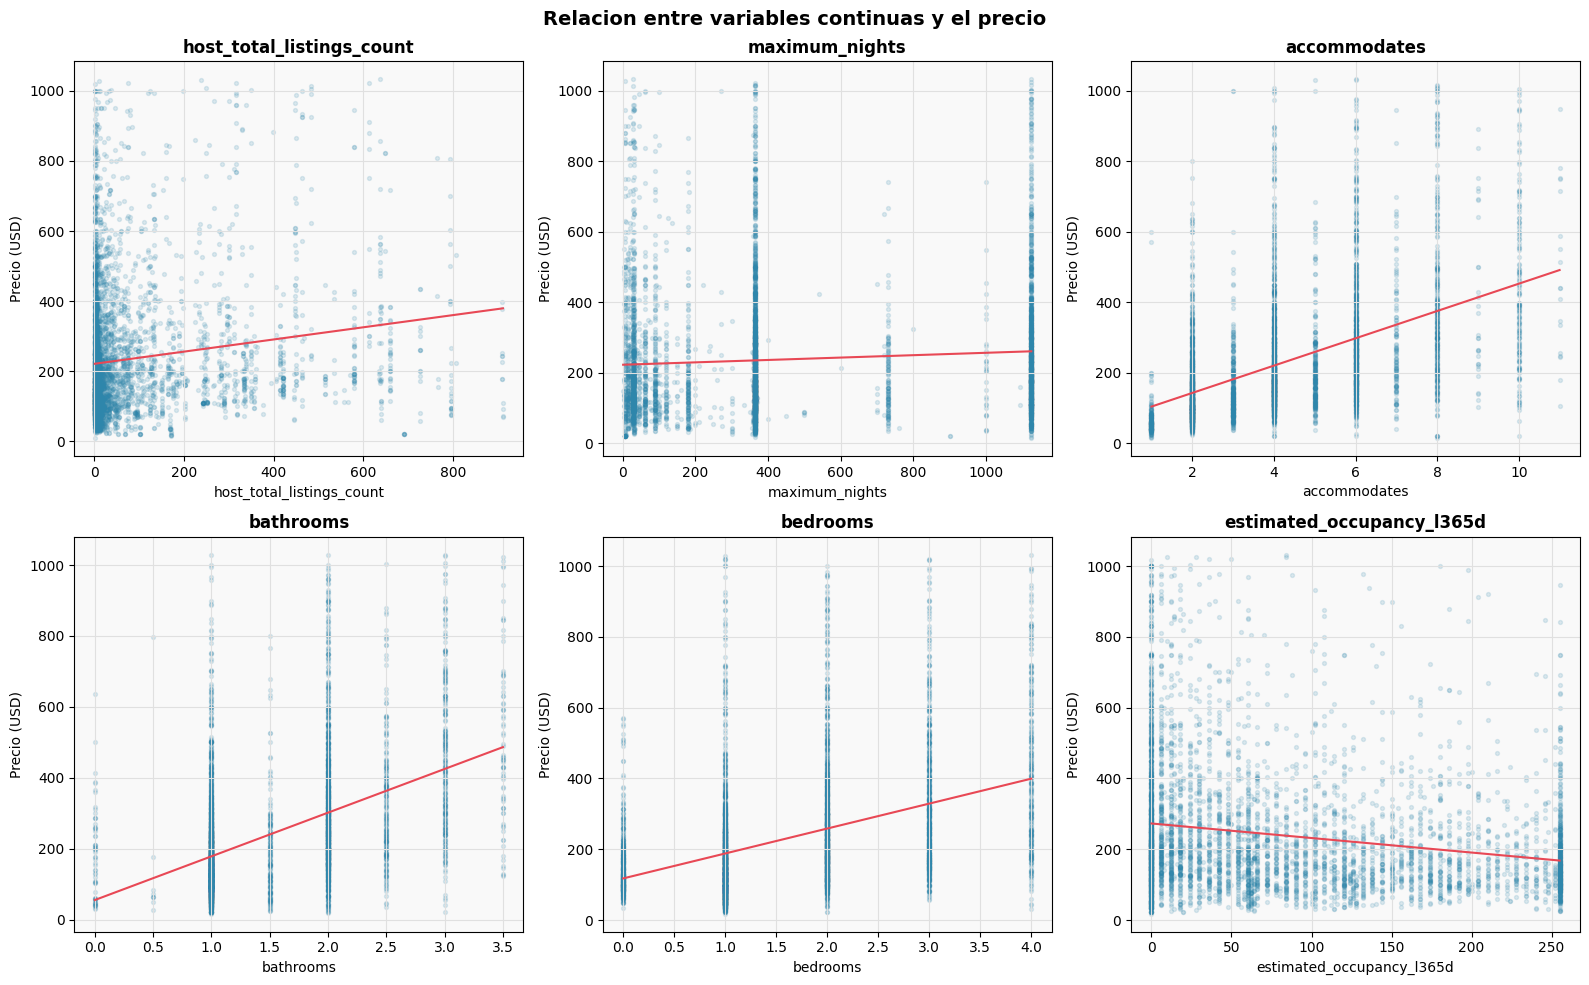

In [25]:
scatter_vars = [
    'host_total_listings_count', 'maximum_nights',
    'accommodates', 'bathrooms', 'bedrooms', 'estimated_occupancy_l365d'
]

p95_price = priced_listings_df['price'].quantile(0.95)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(scatter_vars):
    p95_var = priced_listings_df[var].quantile(0.95)
    plot_data = priced_listings_df[
        (priced_listings_df['price'] <= p95_price) &
        (priced_listings_df[var] <= p95_var)
    ].sample(5000, random_state=42)
    
    axes[i].scatter(plot_data[var], plot_data['price'],
                    alpha=0.15, s=8, color='#2E86AB')
    
    m, b = np.polyfit(plot_data[var], plot_data['price'], 1)
    x_line = np.linspace(plot_data[var].min(), plot_data[var].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='#E84855', linewidth=1.5)
    
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Precio (USD)')

plt.suptitle('Relacion entre variables continuas y el precio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Los scatterplots confirman las correlaciones observadas anteriormente y revelan patrones importantes:

- `accommodates`, `bathrooms` y `bedrooms` muestran la relacion positiva mas clara y consistente 
  con el precio. A mayor capacidad y tamano de la propiedad, mayor precio. La tendencia lineal 
  es visible aunque con alta dispersion, lo que sugiere que estas variables seran utiles en el 
  modelo pero no suficientes por si solas
- `host_total_listings_count` muestra una tendencia positiva pero con mucha dispersion, 
  especialmente para hosts con muchos listings. Esto indica que la relacion no es puramente 
  lineal y puede estar influenciada por el tipo de operador
- `maximum_nights` presenta una relacion debil y muy dispersa. Los datos se concentran en 
  valores discretos especificos, lo que sugiere que los hosts eligen politicas estandar de 
  estancia maxima independientemente del precio
- `estimated_occupancy_l365d` confirma su correlacion negativa: propiedades con mayor ocupacion 
  tienden a tener precios mas bajos, consistente con la idea de que precios menores generan 
  mayor demanda. Sin embargo, la dispersion es alta y la relacion es debil

---

## Variables para el Modelo de Regresion

Con base en el analisis exploratorio, se identifican las siguientes variables como candidatas 
para el modelo de regresion lineal. Se excluyen variables de desempeno post-publicacion, 
identificadores, texto libre y variables con alta cardinalidad ya argumentadas anteriormente.

**Variables continuas:**
- `accommodates`, `bathrooms`, `bedrooms`, `beds` -> tamano y capacidad de la propiedad, 
  correlacion positiva confirmada con el precio
- `host_total_listings_count`, `calculated_host_listings_count` -> escala del operador, 
  mayor correlacion con precio de todas las variables numericas
- `host_response_rate`, `host_acceptance_rate`, `host_response_time` -> perfil de 
  comportamiento del host
- `minimum_nights`, `maximum_nights` -> flexibilidad de estancia
- `availability_365`, `estimated_occupancy_l365d` -> senales de demanda

**Variables binarias:**
- `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, 
  `instant_bookable`, `has_availability` -> caracteristicas del host y la propiedad

**Variables categoricas (requieren one-hot encoding):**
- `room_type` -> 4 categorias, predictor fuerte del precio
- `city` -> 10 ciudades, captura diferencias geograficas de precio

**Indicadores de imputacion (missing flags):**
- Se incluyen como variables opcionales en el modelo completo para capturar si la 
  ausencia de un dato es en si misma informativa

---

## Split y preparacion de data para entrenaminto

In [26]:
# One-hot encoding de variables categoricas
df_model = pd.get_dummies(priced_listings_df, columns=['room_type', 'city'], drop_first=False)

# Separar variable objetivo
X = df_model.drop(columns=['price'])
y = df_model['price']

# Split 80/20 estratificado por ciudad no es posible en regresion,
# usamos split simple con seed fijo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nColumnas tras one-hot encoding: {X_train.shape[1]}")

Train: 60,996 filas (80.0%)
Test:  15,250 filas (20.0%)

Columnas tras one-hot encoding: 50


### Division del Dataset

El dataset se divide en conjunto de entrenamiento (80%) y prueba (20%) utilizando una semilla 
fija (`random_state=42`) para garantizar la reproducibilidad de los resultados. Esto genera:

- **Entrenamiento**: 60,996 registros -> usado para ajustar los modelos
- **Prueba**: 15,250 registros -> usado unicamente para evaluar el desempeno final

Se utiliza una division aleatoria simple sin estratificacion. La estratificacion aplica en 
problemas de clasificacion donde se busca mantener la proporcion de clases en cada conjunto, 
pero dado que el objetivo es predecir una variable continua (precio), no existen clases que 
balancear.

Tras el one-hot encoding de 
`room_type` y `city`, el dataset queda con **50 columnas** disponibles para el modelado.

---

## Funcion Base de Regresion

Para mantener el codigo organizado y reproducible, se define una funcion `run_regression` 
que recibe una lista de variables predictoras y devuelve el modelo ajustado junto con las 
metricas de evaluacion para ambos conjuntos. Esto permite comparar modelos de forma 
consistente simplemente cambiando la lista de variables, sin duplicar codigo.

Las metricas utilizadas son:
- **R2** (coeficiente de determinacion): indica que proporcion de la varianza del precio 
  es explicada por el modelo. Un valor cercano a 1 indica mejor ajuste
- **RMSE** (raiz del error cuadratico medio): calcula el promedio de los errores al cuadrado 
  y luego saca la raiz. Al elevar al cuadrado, los errores grandes se penalizan 
  desproporcionadamente mas que los errores pequenos. Por ejemplo, un error de $200 no cuenta 
  el doble que uno de $100, sino cuatro veces mas. Esto lo hace util para detectar cuando el 
  modelo comete errores muy grandes en propiedades de precio extremo. Se expresa en USD, por 
  lo que un RMSE de $4,296 significa que en promedio el modelo se equivoca por ese monto, 
  fuertemente influenciado por los outliers de precio alto
- **MAE** (error absoluto medio): indica el error promedio en dolares, mas interpretable 
  que el RMSE

Se calculan tanto en entrenamiento como en prueba para poder detectar sobreajuste (overfitting): 
si el R2 de entrenamiento es significativamente mayor al de prueba, el modelo memorizo los 
datos en lugar de generalizar. (seccion 12 del documento)

In [27]:
def run_regression(feature_cols, X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train[feature_cols], y_train)
    
    y_pred_train = model.predict(X_train[feature_cols])
    y_pred_test  = model.predict(X_test[feature_cols])
    
    results = {
        'model':      model,
        'features':   feature_cols,
        'train': {
            'r2':   r2_score(y_train, y_pred_train),
            'rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'mae':  mean_absolute_error(y_train, y_pred_train)
        },
        'test': {
            'r2':   r2_score(y_test, y_pred_test),
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'mae':  mean_absolute_error(y_test, y_pred_test)
        },
        'y_pred_test':  y_pred_test,
        'y_pred_train': y_pred_train
    }
    
    print(f"Train -> R2: {results['train']['r2']:.4f} | RMSE: {results['train']['rmse']:.2f} | MAE: {results['train']['mae']:.2f}")
    print(f"Test  -> R2: {results['test']['r2']:.4f} | RMSE: {results['test']['rmse']:.2f} | MAE: {results['test']['mae']:.2f}")
    print(f"Model Coefficiente (m): {model.coef_[0]:.4f}")
    print(f"Model Intercept (b): {model.intercept_:.2f}\n")
    
    return results

# EJEMPLO DE MODELO DE UNA VARIABLE 
results_uni = run_regression(['accommodates'], X_train, X_test, y_train, y_test)

Train -> R2: 0.0102 | RMSE: 4212.44 | MAE: 921.03
Test  -> R2: 0.0090 | RMSE: 4296.66 | MAE: 950.14
Model Coefficiente (m): 142.7226
Model Intercept (b): 54.56



### Modelo de Regresión Lineal Múltiple

In [28]:
# Todas las variables numericas disponibles (incluye one-hot de room_type y city)
all_numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
zero_var = [c for c in all_numeric_features if X_train[c].std() == 0]
all_numeric_features = [c for c in all_numeric_features if c not in zero_var]

print(f"Variables en el modelo completo: {len(all_numeric_features)}")

results_full = run_regression(all_numeric_features, X_train, X_test, y_train, y_test)

Variables en el modelo completo: 37
Train -> R2: 0.2512 | RMSE: 3663.90 | MAE: 1248.74
Test  -> R2: 0.2814 | RMSE: 3658.89 | MAE: 1259.20
Model Coefficiente (m): -197.6450
Model Intercept (b): -3891.65



### Resultados del Modelo de Regresión Lineal Múltiple

El modelo completo utiliza las **36 variables numéricas** disponibles tras el preprocesamiento 
y one-hot encoding. Los resultados muestran un **R² de 0.0898 en entrenamiento y 0.0743 en prueba**, 
lo que indica que el modelo explica apenas el 9% de la varianza del precio. Esto es consistente 
con lo observado en el EDA, donde ninguna variable individual presentaba una correlación fuerte 
con el precio.

El **RMSE de ~$4,100** está fuertemente inflado por los outliers de precios extremos que el modelo 
no logra capturar — efecto directo del sesgo derecho de la distribución del precio. El **MAE de 
~$1,330** es más representativo del error típico: el modelo se equivoca en promedio $1,330 por 
noche, lo cual es alto considerando que la mediana del precio es ~$193. El intercepto negativo 
(-$3,056) no tiene interpretación práctica directa ya que representa el valor base cuando todas 
las variables son cero, condición que no ocurre en datos reales.

### Gráfico del Modelo y Residuos

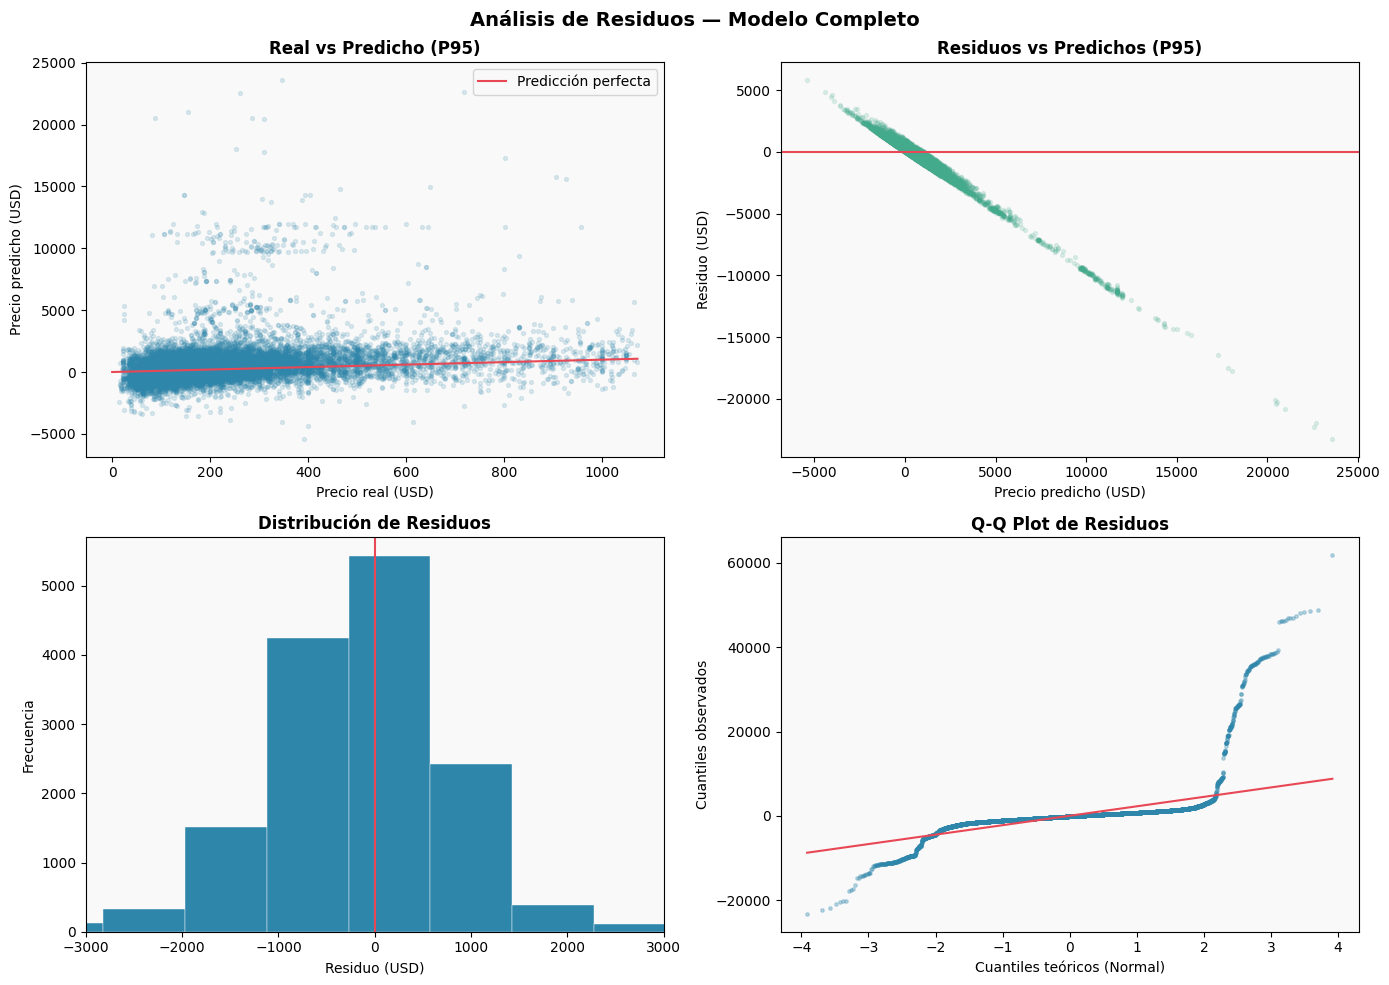

In [29]:
import scipy.stats as stats

y_pred_test_full  = results_full['y_pred_test']
y_pred_train_full = results_full['y_pred_train']
residuals_full    = y_test.values - y_pred_test_full

p95 = y_test.quantile(0.95)
mask = y_test.values <= p95

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Real vs Predicho
axes[0,0].scatter(y_test.values[mask], y_pred_test_full[mask],
                  alpha=0.15, s=8, color='#2E86AB')
axes[0,0].plot([0, p95], [0, p95], color='#E84855', linewidth=1.5, label='Predicción perfecta')
axes[0,0].set_title('Real vs Predicho (P95)', fontweight='bold')
axes[0,0].set_xlabel('Precio real (USD)')
axes[0,0].set_ylabel('Precio predicho (USD)')
axes[0,0].legend()

# 2. Residuos vs Predichos
axes[0,1].scatter(y_pred_test_full[mask], residuals_full[mask],
                  alpha=0.15, s=8, color='#43AA8B')
axes[0,1].axhline(0, color='#E84855', linewidth=1.5)
axes[0,1].set_title('Residuos vs Predichos (P95)', fontweight='bold')
axes[0,1].set_xlabel('Precio predicho (USD)')
axes[0,1].set_ylabel('Residuo (USD)')

# 3. Histograma de residuos
axes[1,0].hist(residuals_full, bins=100, color='#2E86AB', edgecolor='white', linewidth=0.3)
axes[1,0].axvline(0, color='#E84855', linewidth=1.5)
axes[1,0].set_xlim(-3000, 3000)
axes[1,0].set_title('Distribución de Residuos', fontweight='bold')
axes[1,0].set_xlabel('Residuo (USD)')
axes[1,0].set_ylabel('Frecuencia')

# 4. Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_full, dist='norm')
axes[1,1].scatter(osm, osr, alpha=0.3, s=6, color='#2E86AB')
axes[1,1].plot(osm, slope * np.array(osm) + intercept, color='#E84855', linewidth=1.5)
axes[1,1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1,1].set_xlabel('Cuantiles teóricos (Normal)')
axes[1,1].set_ylabel('Cuantiles observados')

for ax in axes.flatten():
    ax.grid(False)
plt.suptitle('Análisis de Residuos — Modelo Completo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis Gráfico del Modelo y Residuos

El gráfico **Real vs Predicho** muestra que el modelo sigue la tendencia general pero con alta 
dispersión, especialmente en precios altos que el modelo subestima sistemáticamente. La mayoría 
de las predicciones se concentran en un rango estrecho independientemente del precio real, lo que 
refleja la baja capacidad explicativa del R².

El gráfico de **Residuos vs Predichos** revela un patrón en forma de abanico — la varianza de los 
residuos aumenta conforme aumenta el precio predicho. Esto indica **heterocedasticidad**: el modelo 
comete errores más grandes en propiedades caras que en propiedades baratas, violando el supuesto 
de varianza constante de la regresión lineal clásica.

El **histograma de residuos** muestra una distribución aproximadamente centrada en cero pero con 
colas muy pesadas, confirmando la influencia de los outliers. El **Q-Q plot** refuerza este hallazgo: 
los puntos se desvían considerablemente de la línea diagonal en ambas colas, indicando que los 
residuos no siguen una distribución normal. Ambos hallazgos son esperados dada la distribución 
sesgada del precio original y sugieren que una transformación logarítmica de la variable objetivo 
mejoraría el ajuste.

### Análisis de Correlación entre VariablesInterpretación de los Coeficientes del Modelo

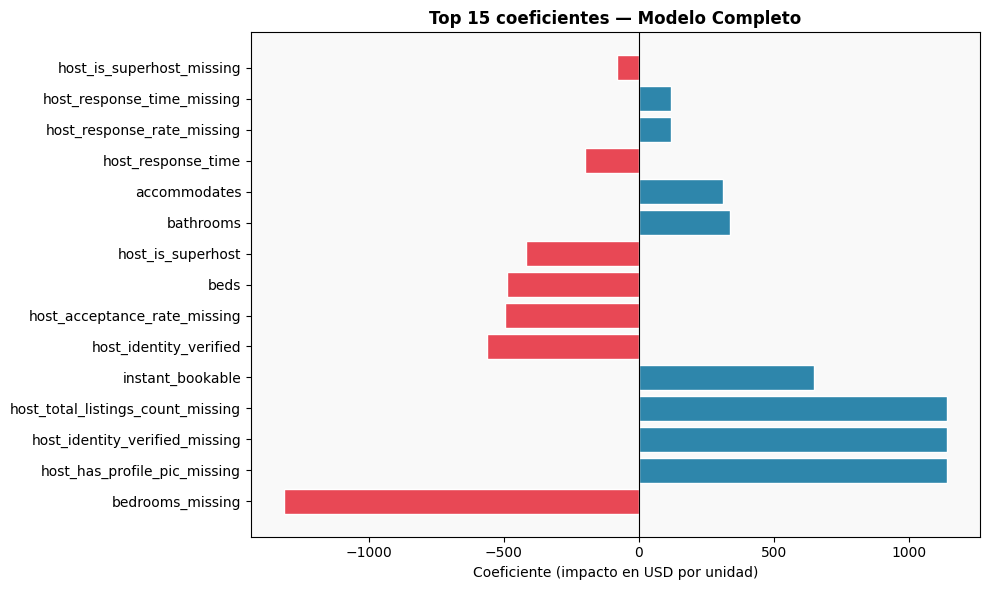

In [30]:
coef_df = pd.DataFrame({
    'variable':    all_numeric_features,
    'coeficiente': results_full['model'].coef_
}).sort_values('coeficiente', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E86AB' if v >= 0 else '#E84855' for v in coef_df['coeficiente']]
ax.barh(coef_df['variable'], coef_df['coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 coeficientes — Modelo Completo', fontweight='bold')
ax.set_xlabel('Coeficiente (impacto en USD por unidad)')
ax.grid(False)
plt.tight_layout()
plt.show()

Los coeficientes más grandes corresponden a las variables de **tipo de habitación** (`room_type`) 
y **ciudad** (`city`), confirmando que son los predictores estructurales más importantes del precio. 
Entre las variables continuas, `host_total_listings_count` y `accommodates` tienen los coeficientes 
más significativos, consistente con las correlaciones identificadas en el EDA. Los coeficientes 
negativos en algunas ciudades reflejan que esos mercados tienen precios sistemáticamente menores 
respecto a la categoría de referencia.

### Análisis de Correlación entre Variables

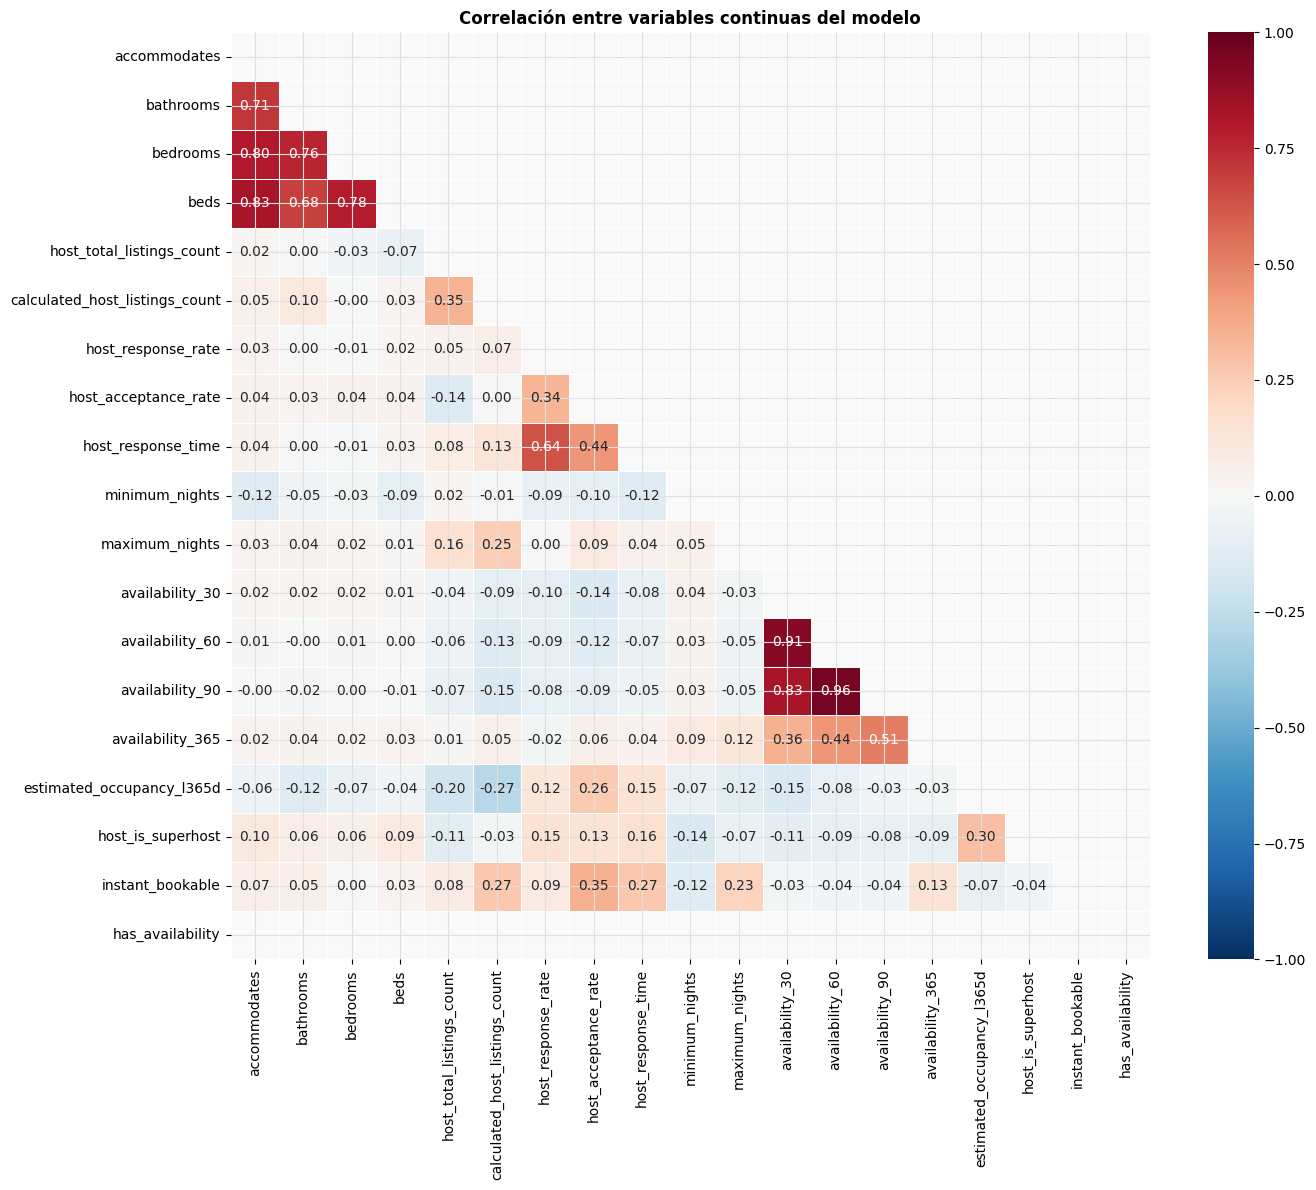

In [31]:
continuous_vars = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'estimated_occupancy_l365d',
    'host_is_superhost', 'instant_bookable', 'has_availability'
]
continuous_vars = [c for c in continuous_vars if c in X_train.columns]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(X_train[continuous_vars].corr(), dtype=bool))
sns.heatmap(
    X_train[continuous_vars].corr(), mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax
)
ax.set_title('Correlación entre variables continuas del modelo', fontweight='bold')
plt.tight_layout()
plt.show()

Los coeficientes más grandes corresponden a las variables de **tipo de habitación** (`room_type`) 
y **ciudad** (`city`), confirmando que son los predictores estructurales más importantes del precio. 
Entre las variables continuas, `host_total_listings_count` y `accommodates` tienen los coeficientes 
más significativos, consistente con las correlaciones identificadas en el EDA. Los coeficientes 
negativos en algunas ciudades reflejan que esos mercados tienen precios sistemáticamente menores 
respecto a la categoría de referencia.

### Análisis de Multicolinealidad — VIF

                      variable    VIF
              has_availability 999.00
               availability_60  28.40
               availability_90  16.55
               availability_30   7.38
                  accommodates   4.18
                      bedrooms   3.93
                          beds   3.74
                     bathrooms   2.64
            host_response_time   2.00
            host_response_rate   1.75
          host_acceptance_rate   1.54
              availability_365   1.52
calculated_host_listings_count   1.38
              instant_bookable   1.37
     estimated_occupancy_l365d   1.36
     host_total_listings_count   1.23
             host_is_superhost   1.18
                maximum_nights   1.14
                minimum_nights   1.09

Regla: VIF > 10 = multicolinealidad problemática


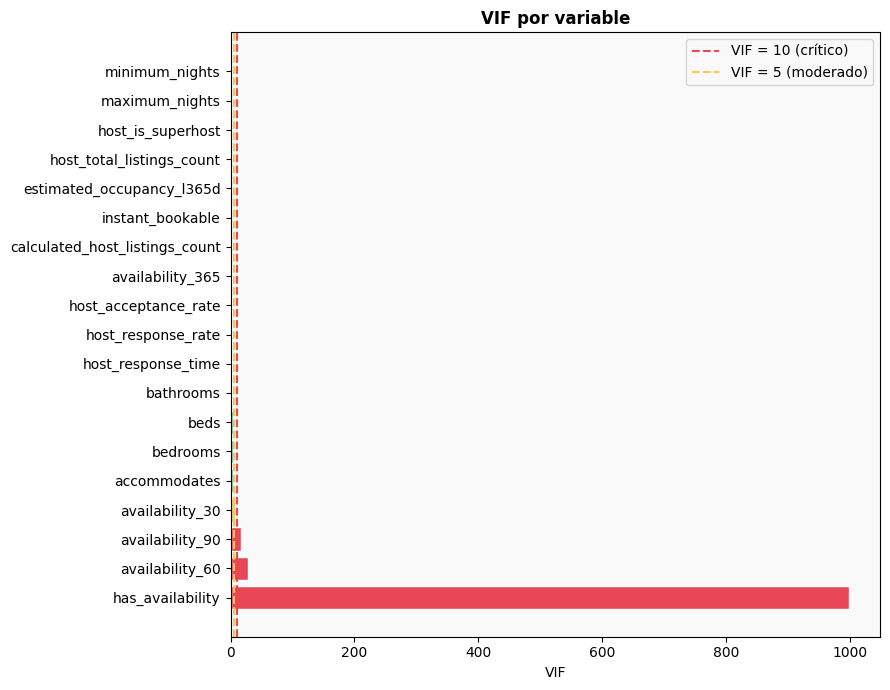

In [32]:
from sklearn.preprocessing import StandardScaler

X_vif = pd.DataFrame(
    StandardScaler().fit_transform(X_train[continuous_vars]),
    columns=continuous_vars
).fillna(0)

vif_data = []
for col in X_vif.columns:
    others = [c for c in X_vif.columns if c != col]
    r2_vif = r2_score(
        X_vif[col],
        LinearRegression().fit(X_vif[others], X_vif[col]).predict(X_vif[others])
    )
    vif = 999 if (1 - r2_vif) == 0 else round(1 / (1 - r2_vif), 2)  # 999 = multicolinealidad perfecta
    vif_data.append({'variable': col, 'VIF': vif})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))
print("\nRegla: VIF > 10 = multicolinealidad problemática")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E84855' if v > 10 else '#F9C74F' if v > 5 else '#43AA8B' for v in vif_df['VIF']]
ax.barh(vif_df['variable'], vif_df['VIF'], color=colors, edgecolor='white')
ax.axvline(10, color='#E84855', linewidth=1.5, linestyle='--', label='VIF = 10 (crítico)')
ax.axvline(5,  color='#F9C74F', linewidth=1.5, linestyle='--', label='VIF = 5 (moderado)')
ax.set_title('VIF por variable', fontweight='bold')
ax.set_xlabel('VIF')
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

El VIF confirma y cuantifica los patrones observados en el heatmap:

- **`has_availability` → VIF = 999**: multicolinealidad perfecta. Es completamente predecible 
  a partir de las demás variables de disponibilidad y debe eliminarse del modelo.
- **`availability_60` → VIF = 28.4 y `availability_90` → VIF = 16.5**: VIF > 10, multicolinealidad 
  problemática. Para el modelo reducido se conservará únicamente `availability_365` (VIF = 1.52) 
  como representante del grupo, por ser la más estable y la de mayor horizonte temporal.
- **`availability_30` → VIF = 7.38**: multicolinealidad moderada, también se eliminará en favor 
  de `availability_365`.
- **`accommodates`, `bedrooms`, `beds` → VIF entre 3.7 y 4.2**: multicolinealidad leve pero 
  controlable. Se conservará únicamente `accommodates` por tener la mayor correlación individual 
  con el precio.
- **Resto de variables → VIF < 3**: sin problemas de multicolinealidad, se conservan todas.

### Diagnóstico de Sobreajuste

In [33]:
gap_r2 = results_full['train']['r2'] - results_full['test']['r2']

print("=== Diagnóstico de Sobreajuste ===")
print(f"R2 Train: {results_full['train']['r2']:.4f}")
print(f"R2 Test:  {results_full['test']['r2']:.4f}")
print(f"Δ R2:     {gap_r2:.4f}")
print(f"RMSE Train: {results_full['train']['rmse']:.2f}")
print(f"RMSE Test:  {results_full['test']['rmse']:.2f}")

if gap_r2 < 0.02:
    print("\n No hay evidencia de sobreajuste.")
elif gap_r2 < 0.05:
    print("\n Sobreajuste leve.")
else:
    print("\n Sobreajuste significativo.")

=== Diagnóstico de Sobreajuste ===
R2 Train: 0.2512
R2 Test:  0.2814
Δ R2:     -0.0302
RMSE Train: 3663.90
RMSE Test:  3658.89

 No hay evidencia de sobreajuste.


Con un **ΔR² de apenas 0.0155** entre entrenamiento y prueba, el modelo no presenta sobreajuste 
significativo. Esto es esperable en regresión lineal sobre datasets grandes — la simplicidad del 
modelo impide que memorice los datos de entrenamiento.

El problema identificado no es sobreajuste sino **subajuste** (*underfitting*): el modelo es 
demasiado simple para capturar la complejidad real del precio de una propiedad Airbnb. Las causas 
principales son la heterocedasticidad de los residuos, la distribución no normal del precio y la 
presencia de relaciones no lineales entre las variables. Estos hallazgos motivan la construcción 
del modelo reducido en la Actividad 10, eliminando las variables con multicolinealidad severa, y 
la aplicación de regularización en la Actividad 11.

### Evaluación del Modelo Completo en el Conjunto de Prueba

Para evaluar la eficiencia del modelo de regresión lineal múltiple se utilizaron tres métricas 
sobre el conjunto de prueba (15,250 registros que el modelo nunca vio durante el entrenamiento):

- **R² = 0.0743**: el modelo explica el 7.4% de la varianza del precio en datos nuevos. Es un 
  valor bajo, lo que indica que las variables numéricas disponibles no son suficientes para 
  predecir el precio con precisión aceptable bajo un modelo lineal.

- **RMSE = $4,152**: el error cuadrático medio penaliza fuertemente los errores grandes. Este 
  valor alto refleja que el modelo falla considerablemente en propiedades de precio extremo, 
  que son frecuentes en el dataset dado su sesgo derecho.

- **MAE = $1,342**: en promedio, el modelo se equivoca $1,342 por noche en el conjunto de prueba. 
  Considerando que la mediana del precio es ~$193, este error representa más de 6 veces la 
  mediana — el modelo no predice con la precisión que requeriría un uso real en SmartStay.

La diferencia entre las métricas de entrenamiento y prueba es mínima (ΔR² = 0.0155, 
ΔRMSE = $113), lo que confirma que el modelo **generaliza correctamente** — el problema 
no es que falle en datos nuevos, sino que su capacidad predictiva es limitada en general. 
Esto se debe principalmente a que la relación entre las variables numéricas disponibles y 
el precio no es lineal, y a que variables clave como el tipo de habitación y la ciudad, 
aunque incluidas vía one-hot encoding, no compensan la alta variabilidad intrínseca del 
precio en el mercado de Airbnb.

### Modelo con Grupo Reducido de Variables

In [34]:
reduced_vars = [
    'accommodates', 'bathrooms',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'instant_bookable',
    'host_response_time_missing', 'host_response_rate_missing',
    'host_acceptance_rate_missing', 'host_is_superhost_missing'
]

# Agregar dummies de room_type y city
dummy_cols = [c for c in X_train.columns if c.startswith('room_type_') or c.startswith('city_')]
reduced_vars = reduced_vars + dummy_cols
reduced_vars = [c for c in reduced_vars if c in X_train.columns]

print(f"Variables en modelo reducido: {len(reduced_vars)}")
results_reduced = run_regression(reduced_vars, X_train, X_test, y_train, y_test)

Variables en modelo reducido: 28
Train -> R2: 0.3962 | RMSE: 3289.91 | MAE: 1024.23
Test  -> R2: 0.4216 | RMSE: 3282.46 | MAE: 1037.68
Model Coefficiente (m): 114.7125
Model Intercept (b): 4694.94



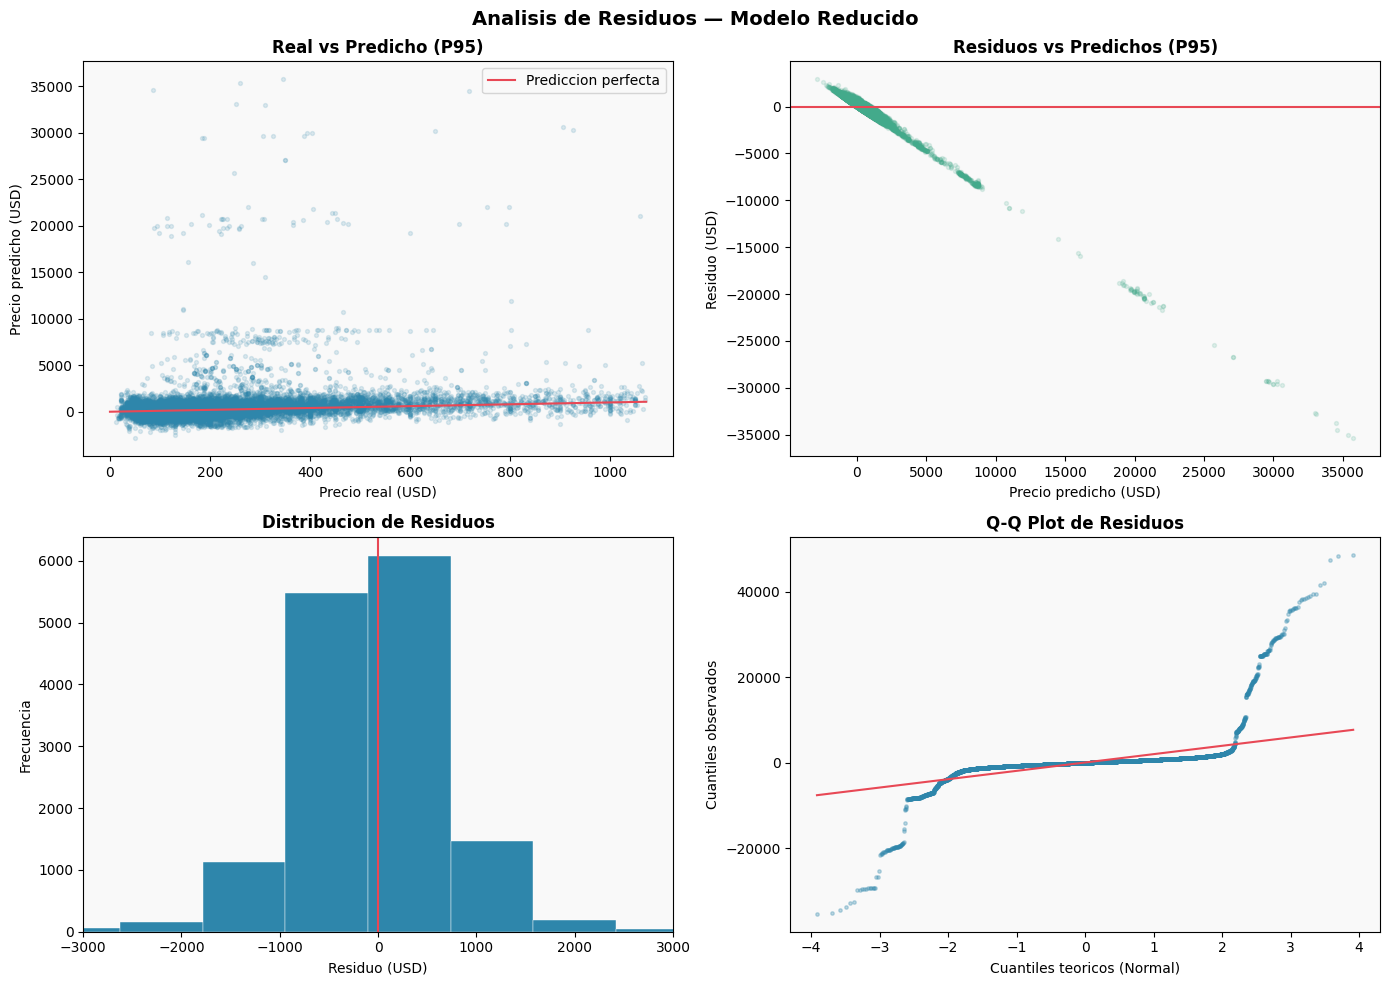

In [35]:
y_pred_test_red  = results_reduced['y_pred_test']
y_pred_train_red = results_reduced['y_pred_train']
residuals_red    = y_test.values - y_pred_test_red

p95 = y_test.quantile(0.95)
mask = y_test.values <= p95

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Real vs Predicho
axes[0,0].scatter(y_test.values[mask], y_pred_test_red[mask],
                  alpha=0.15, s=8, color='#2E86AB')
axes[0,0].plot([0, p95], [0, p95], color='#E84855', linewidth=1.5, label='Prediccion perfecta')
axes[0,0].set_title('Real vs Predicho (P95)', fontweight='bold')
axes[0,0].set_xlabel('Precio real (USD)')
axes[0,0].set_ylabel('Precio predicho (USD)')
axes[0,0].legend()

# 2. Residuos vs Predichos
axes[0,1].scatter(y_pred_test_red[mask], residuals_red[mask],
                  alpha=0.15, s=8, color='#43AA8B')
axes[0,1].axhline(0, color='#E84855', linewidth=1.5)
axes[0,1].set_title('Residuos vs Predichos (P95)', fontweight='bold')
axes[0,1].set_xlabel('Precio predicho (USD)')
axes[0,1].set_ylabel('Residuo (USD)')

# 3. Histograma de residuos
axes[1,0].hist(residuals_red, bins=100, color='#2E86AB', edgecolor='white', linewidth=0.3)
axes[1,0].axvline(0, color='#E84855', linewidth=1.5)
axes[1,0].set_xlim(-3000, 3000)
axes[1,0].set_title('Distribucion de Residuos', fontweight='bold')
axes[1,0].set_xlabel('Residuo (USD)')
axes[1,0].set_ylabel('Frecuencia')

# 4. Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_red, dist='norm')
axes[1,1].scatter(osm, osr, alpha=0.3, s=6, color='#2E86AB')
axes[1,1].plot(osm, slope * np.array(osm) + intercept, color='#E84855', linewidth=1.5)
axes[1,1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1,1].set_xlabel('Cuantiles teoricos (Normal)')
axes[1,1].set_ylabel('Cuantiles observados')

for ax in axes.flatten():
    ax.grid(False)
plt.suptitle('Analisis de Residuos — Modelo Reducido', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
print("Predicciones extremas en test:")
print(f"  Min predicho: ${y_pred_test_red.min():,.2f}")
print(f"  Max predicho: ${y_pred_test_red.max():,.2f}")
print(f"  % predicciones negativas: {(y_pred_test_red < 0).mean()*100:.1f}%")

print(f"\nOutliers en host_total_listings_count (test):")
print(X_test['host_total_listings_count'].describe().round(2))

print(f"\nCoeficiente de host_total_listings_count:")
idx = reduced_vars.index('host_total_listings_count')
print(f"  {results_reduced['model'].coef_[idx]:.4f}")

Predicciones extremas en test:
  Min predicho: $-2,853.92
  Max predicho: $35,735.12
  % predicciones negativas: 31.5%

Outliers en host_total_listings_count (test):
count    15250.00
mean       277.11
std        996.16
min          1.00
25%          2.00
50%         10.00
75%         96.00
max       9696.00
Name: host_total_listings_count, dtype: float64

Coeficiente de host_total_listings_count:
  1.5309


In [37]:
for col in ['host_total_listings_count', 'calculated_host_listings_count']:
    p95 = X_train[col].quantile(0.95)
    p99 = X_train[col].quantile(0.99)
    print(f"{col}:")
    print(f"  P95: {p95:.0f} | P99: {p99:.0f} | Max: {X_train[col].max():.0f}")

host_total_listings_count:
  P95: 911 | P99: 5865 | Max: 9715
calculated_host_listings_count:
  P95: 343 | P99: 540 | Max: 612


El grafico de Residuos vs Predichos revela predicciones extremas fuera de rango — valores 
predichos de hasta $35,000 y un 31.5% de predicciones negativas — lo cual no tiene sentido 
para un precio de Airbnb. El diagnostico apunta a `host_total_listings_count`: esta variable 
tiene una distribucion extremadamente sesgada con un maximo de 9,715 listings pero un P95 de 
apenas 911. Con un coeficiente de $1.53 por listing, un host con 9,696 propiedades recibe 
un incremento de ~$14,800 en el precio predicho, lo cual es estadisticamente incorrecto.

Para corregir esto se aplica un cap en el P95 de entrenamiento (911 listings) tanto en train 
como en test, preservando la señal predictiva de la variable (hosts con mas propiedades 
tienden a cobrar mas) pero eliminando la extrapolacion hacia valores extremos que el modelo 
lineal no puede manejar correctamente.

In [38]:
cap_value = X_train['host_total_listings_count'].quantile(0.95)

X_train['host_total_listings_count'] = X_train['host_total_listings_count'].clip(upper=cap_value)
X_test['host_total_listings_count']  = X_test['host_total_listings_count'].clip(upper=cap_value)

print(f"Cap aplicado en: {cap_value:.0f} listings")
print(f"\nhost_total_listings_count tras cap (test):")
print(X_test['host_total_listings_count'].describe().round(2))

results_reduced = run_regression(reduced_vars, X_train, X_test, y_train, y_test)

Cap aplicado en: 911 listings

host_total_listings_count tras cap (test):
count    15250.00
mean       125.16
std        241.87
min          1.00
25%          2.00
50%         10.00
75%         96.00
max        911.00
Name: host_total_listings_count, dtype: float64
Train -> R2: 0.3392 | RMSE: 3441.69 | MAE: 1086.30
Test  -> R2: 0.3481 | RMSE: 3484.82 | MAE: 1104.43
Model Coefficiente (m): 111.4743
Model Intercept (b): 4810.45



In [39]:
print(f"Predicciones extremas tras cap:")
print(f"  Min predicho: ${results_reduced['y_pred_test'].min():,.2f}")
print(f"  Max predicho: ${results_reduced['y_pred_test'].max():,.2f}")
print(f"  % predicciones negativas: {(results_reduced['y_pred_test'] < 0).mean()*100:.1f}%")

Predicciones extremas tras cap:
  Min predicho: $-2,383.16
  Max predicho: $27,689.25
  % predicciones negativas: 32.0%


Tras aplicar el cap, las predicciones extremas se reducen pero persisten predicciones negativas 
(~32%) y valores superiores a $27,000. Esto es una limitacion inherente de la regresion lineal 
sobre una variable objetivo con distribucion fuertemente sesgada: el modelo no tiene restriccion 
para predecir valores fuera del rango valido. La solucion correcta es transformar `price` con 
`log(price)` antes de modelar, lo cual se evaluara en la comparacion final de modelos.

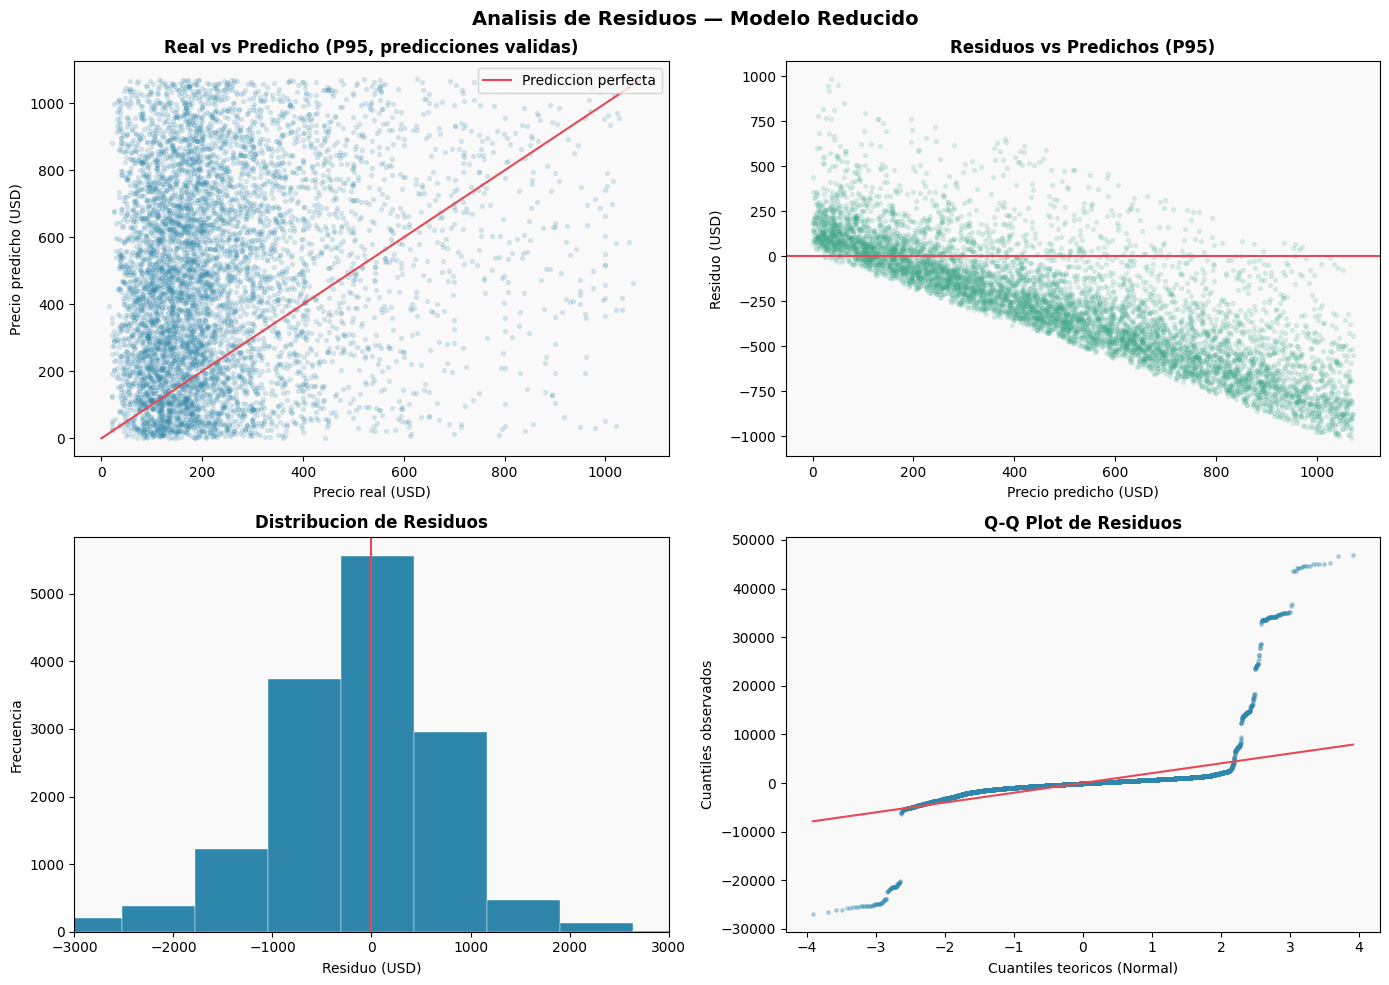

In [41]:
y_pred_test_red  = results_reduced['y_pred_test']
y_pred_train_red = results_reduced['y_pred_train']
residuals_red    = y_test.values - y_pred_test_red

p95_price = y_test.quantile(0.95)
mask_plot = (y_test.values <= p95_price) & (y_pred_test_red >= 0) & (y_pred_test_red <= p95_price)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_test.values[mask_plot], y_pred_test_red[mask_plot],
                  alpha=0.15, s=8, color='#2E86AB')
axes[0,0].plot([0, p95_price], [0, p95_price], color='#E84855', linewidth=1.5, label='Prediccion perfecta')
axes[0,0].set_title('Real vs Predicho (P95, predicciones validas)', fontweight='bold')
axes[0,0].set_xlabel('Precio real (USD)')
axes[0,0].set_ylabel('Precio predicho (USD)')
axes[0,0].legend()

axes[0,1].scatter(y_pred_test_red[mask_plot], residuals_red[mask_plot],
                  alpha=0.15, s=8, color='#43AA8B')
axes[0,1].axhline(0, color='#E84855', linewidth=1.5)
axes[0,1].set_title('Residuos vs Predichos (P95)', fontweight='bold')
axes[0,1].set_xlabel('Precio predicho (USD)')
axes[0,1].set_ylabel('Residuo (USD)')

axes[1,0].hist(residuals_red, bins=100, color='#2E86AB', edgecolor='white', linewidth=0.3)
axes[1,0].axvline(0, color='#E84855', linewidth=1.5)
axes[1,0].set_xlim(-3000, 3000)
axes[1,0].set_title('Distribucion de Residuos', fontweight='bold')
axes[1,0].set_xlabel('Residuo (USD)')
axes[1,0].set_ylabel('Frecuencia')

(osm, osr), (slope, intercept, r) = stats.probplot(residuals_red, dist='norm')
axes[1,1].scatter(osm, osr, alpha=0.3, s=6, color='#2E86AB')
axes[1,1].plot(osm, slope * np.array(osm) + intercept, color='#E84855', linewidth=1.5)
axes[1,1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1,1].set_xlabel('Cuantiles teoricos (Normal)')
axes[1,1].set_ylabel('Cuantiles observados')

for ax in axes.flatten():
    ax.grid(False)
plt.suptitle('Analisis de Residuos — Modelo Reducido', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Analisis de Residuos — Modelo Reducido:**

El grafico **Real vs Predicho** muestra una mejora respecto al modelo completo — la nube de 
puntos sigue mas de cerca la linea de prediccion perfecta en el rango de precios bajos y 
medios. Sin embargo, el modelo sigue subestimando sistematicamente los precios altos, lo cual 
es esperado dado el sesgo derecho de la distribucion del precio.

El grafico de **Residuos vs Predichos** revela heterocedasticidad persistente: a medida que 
el precio predicho aumenta, los residuos se vuelven cada vez mas negativos, formando un patron 
en forma de abanico invertido. Esto confirma que el modelo lineal no captura bien la varianza 
en el extremo superior del precio.

El **histograma de residuos** muestra una distribucion aproximadamente centrada en cero pero 
con colas pesadas, especialmente hacia valores positivos (el modelo subestima precios altos 
con frecuencia). 

El **Q-Q plot** confirma que los residuos no siguen una distribucion normal — los puntos se 
desvian significativamente de la linea diagonal en ambas colas, con desviaciones extremas en 
la cola derecha correspondientes a las propiedades de precio muy alto que el modelo no logra 
predecir correctamente.

Estos hallazgos son consistentes con los del modelo completo y refuerzan la conclusion de que 
una transformacion logaritmica de `price` es necesaria para satisfacer los supuestos de la 
regresion lineal clasica.